In [19]:
import pandas as pd
import pandasql as psql
import duckdb
import requests as rq
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s:%(name)s:%(message)s')

In [20]:
url = "https://www.kaggle.com/datasets/kunalgp/top-1000-most-played-spotify-songs-of-all-time"

response = rq.get(url)
print(response.status_code)

def get_csv_links(url):
    response = rq.get(url)
    if response.status_code == 200:
        soup = BeautifulSoup(response.content, 'html.parser')
        # Look for <a> tags with links to CSV files
        for link in soup.find_all('a', href=True):
            href = link['href']
            if href.endswith('.csv'):
                logging.info("Found CSV link:", href)
                return href
        else:
            logging.error("No CSV link found on the page.")
    else:
        logging.error("Failed to access the page. Status code:", response.status_code)
    
    return None

get_csv_links(url)

200


ERROR:root:No CSV link found on the page.


Problem that you have to use Kaggle's API(Yes, before starting i didn't know that...) and i just decided to easily download it as a csv file :)

In [21]:
df = pd.read_csv('spotify_top_1000_tracks.csv', low_memory=True, encoding='utf-8')

df['release_date'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce')

df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

print(df[['release_date', 'release_year', 'release_month']].head())
print(df.dtypes)

  release_date  release_year  release_month
0   2018-02-09          2018              2
1   2016-11-25          2016             11
2   2019-06-21          2019              6
3   2020-08-07          2020              8
4   2016-08-05          2016              8
track_name               object
artist                   object
album                    object
release_date     datetime64[ns]
popularity                int64
spotify_url              object
id                       object
duration_min            float64
release_year              int32
release_month             int32
dtype: object


In [22]:
df.head()

,track_name,artist,album,release_date,popularity,spotify_url,id,duration_min,release_year,release_month
0,All The Stars (with SZA),Kendrick Lamar,Black Panther The Album Music From And Inspire...,2018-02-09,95,https://open.spotify.com/track/3GCdLUSnKSMJhs4...,3GCdLUSnKSMJhs4Tj6CV3s,3.869767,2018,2
1,Starboy,The Weeknd,Starboy,2016-11-25,90,https://open.spotify.com/track/7MXVkk9YMctZqd1...,7MXVkk9YMctZqd1Srtv4MB,3.840883,2016,11
2,Señorita,Shawn Mendes,Señorita,2019-06-21,80,https://open.spotify.com/track/0TK2YIli7K1leLo...,0TK2YIli7K1leLovkQiNik,3.182667,2019,6
3,Heat Waves,Glass Animals,Dreamland,2020-08-07,87,https://open.spotify.com/track/3USxtqRwSYz57Ew...,3USxtqRwSYz57Ewm6wWRMp,3.980083,2020,8
4,Let Me Love You,DJ Snake,Encore,2016-08-05,87,https://open.spotify.com/track/0lYBSQXN6rCTvUZ...,0lYBSQXN6rCTvUZvg9S0lU,3.432433,2016,8


In [23]:
popular_track_by_artist = duckdb.sql("""
    SELECT artist, track_name, popularity
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY artist ORDER BY popularity DESC) AS rank
        FROM df
        WHERE popularity >= 90
    )
    WHERE rank = 1
    ORDER BY popularity DESC
""").df()

popular_track_by_artist

,artist,track_name,popularity
0,Gracie Abrams,That’s So True,97
1,ROSÉ,APT.,96
2,Kendrick Lamar,All The Stars (with SZA),95
3,The Weeknd,"One Of The Girls (with JENNIE, Lily Rose Depp)",93
4,Arctic Monkeys,I Wanna Be Yours,93
5,WizTheMc,Show Me Love,92
6,Coldplay,Yellow,92
7,yung kai,blue,92
8,The Neighbourhood,Sweater Weather,92
9,Djo,End of Beginning,90


In [37]:
import pandasql as psql

query = """
    SELECT artist, track_name, popularity
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY artist ORDER BY popularity DESC) AS rank
        FROM df
        WHERE popularity >= 90
    )
    WHERE rank = 1
    ORDER BY popularity DESC
"""
result = psql.sqldf(query, globals())
result

,artist,track_name,popularity
0,Gracie Abrams,That’s So True,97
1,ROSÉ,APT.,96
2,Kendrick Lamar,All The Stars (with SZA),95
3,Arctic Monkeys,I Wanna Be Yours,93
4,The Weeknd,"One Of The Girls (with JENNIE, Lily Rose Depp)",93
5,Coldplay,Yellow,92
6,The Neighbourhood,Sweater Weather,92
7,WizTheMc,Show Me Love,92
8,yung kai,blue,92
9,Billie Eilish,CHIHIRO,90


**Just tried to get the most popular tracks by artist using DuckDB and SQL on Pandas Dataframe**

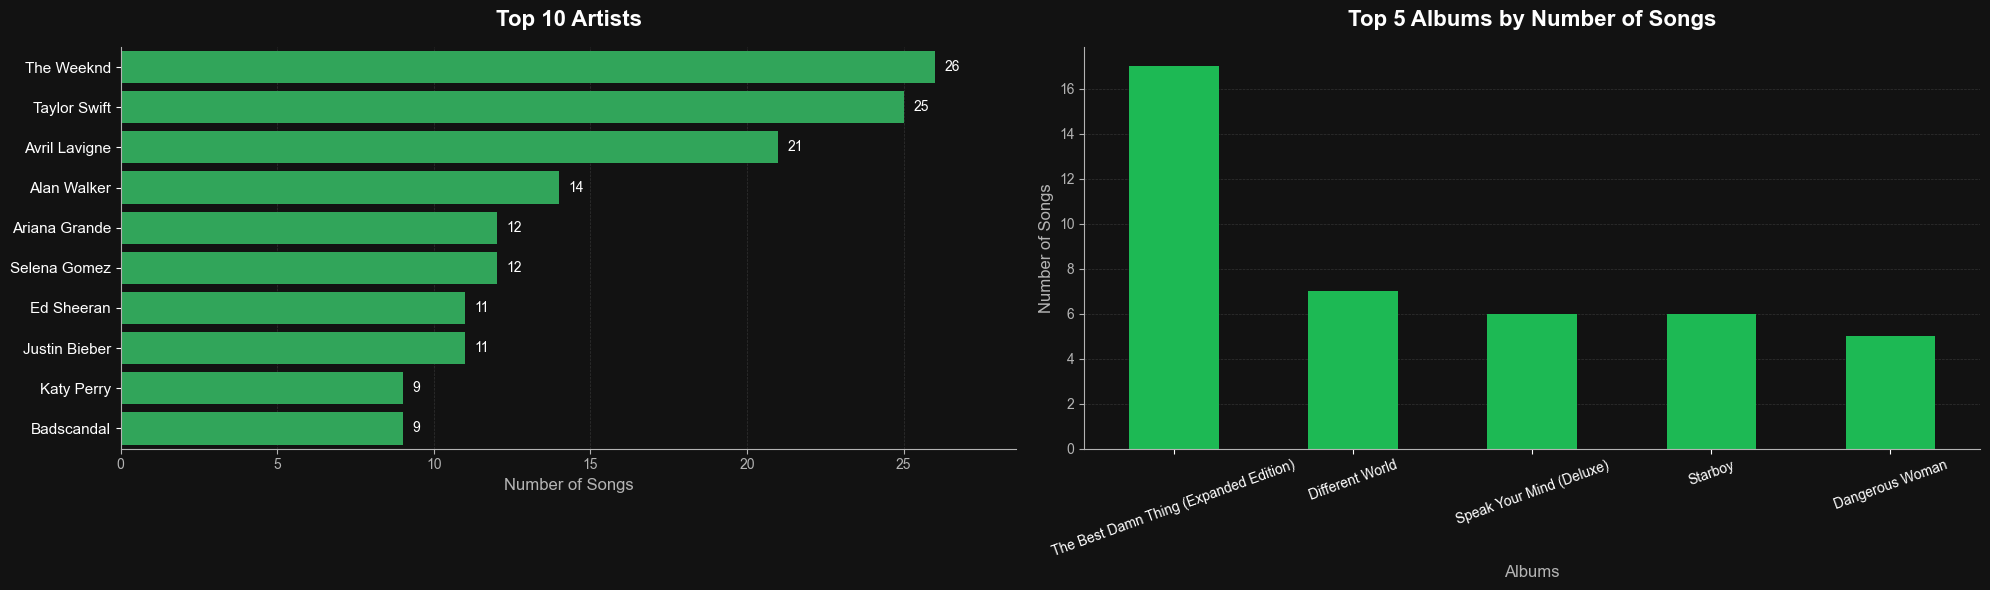

In [25]:
top_albums = df['album'].value_counts().head(5)

# --- Spotify Styling ---
spotify_black = '#121212'
spotify_green = '#1DB954'
spotify_light_grey = '#B3B3B3'
spotify_white = '#FFFFFF'

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Bitstream Vera Sans', 'sans-serif']

# --- Create Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6), facecolor=spotify_black)
for ax in axes:
    ax.set_facecolor(spotify_black)

# --- Plot 1: Top 10 Artists ---
top_artists = df['artist'].value_counts().head(10)
sns.barplot(x=top_artists.values, y=top_artists.index, ax=axes[0], color=spotify_green)

axes[0].set_title('Top 10 Artists', color=spotify_white, fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Songs', color=spotify_light_grey, fontsize=12)
axes[0].set_ylabel(None)
axes[0].tick_params(axis='x', colors=spotify_light_grey, labelsize=10)
axes[0].tick_params(axis='y', colors=spotify_white, labelsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_color(spotify_light_grey)
axes[0].spines['left'].set_color(spotify_light_grey)
axes[0].grid(True, axis='x', linestyle='--', linewidth=0.5, color='#404040', alpha=0.7)
axes[0].set_axisbelow(True)

for i, v in enumerate(top_artists.values):
    axes[0].text(v + 0.3, i, str(v), color=spotify_white, va='center', fontsize=10, fontweight='medium')

axes[0].set_xlim(right=top_artists.values.max() * 1.1)

# --- Plot 2: Top 5 Albums ---
top_albums.plot(kind='bar', color=spotify_green, ax=axes[1])

axes[1].set_title('Top 5 Albums by Number of Songs', color=spotify_white, fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Albums', color=spotify_light_grey, fontsize=12)
axes[1].set_ylabel('Number of Songs', color=spotify_light_grey, fontsize=12)
axes[1].tick_params(axis='x', colors=spotify_white, labelsize=10, rotation=20)
axes[1].tick_params(axis='y', colors=spotify_light_grey, labelsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_color(spotify_light_grey)
axes[1].spines['left'].set_color(spotify_light_grey)
axes[1].grid(True, axis='y', linestyle='--', linewidth=0.5, color='#404040', alpha=0.7)
axes[1].set_axisbelow(True)

# --- Final Layout ---
plt.tight_layout()
plt.show()
plt.close(fig)

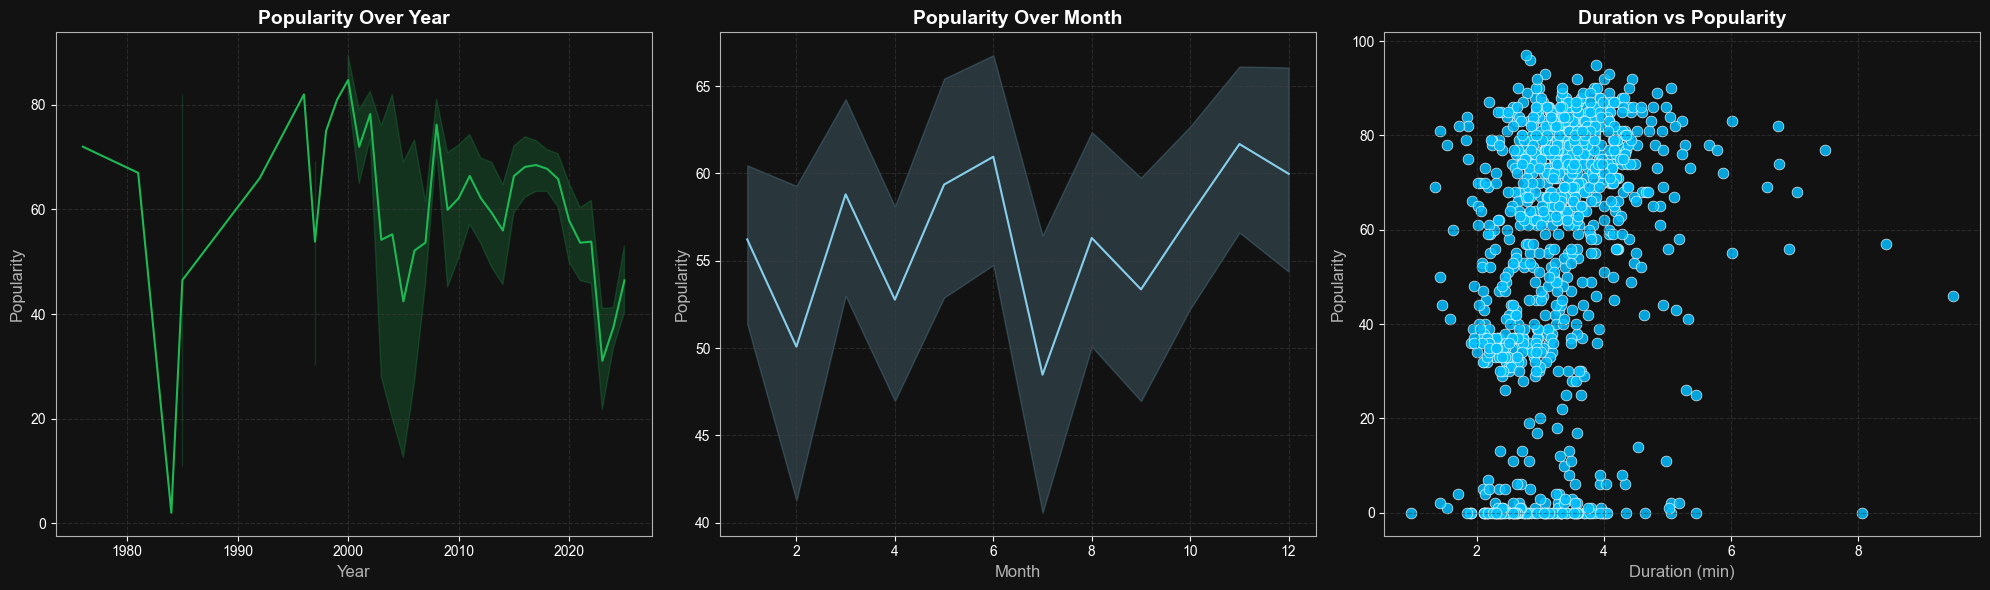

In [26]:
# --- Create Subplots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=spotify_black)
for ax in axes:
    ax.set_facecolor(spotify_black)

# --- 1. Popularity Over Year ---
sns.lineplot(x=df['release_year'], y=df['popularity'], ax=axes[0], color=spotify_green)
axes[0].set_title('Popularity Over Year', color=spotify_white, fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12, color=spotify_light_grey)
axes[0].set_ylabel('Popularity', fontsize=12, color=spotify_light_grey)
axes[0].tick_params(colors=spotify_white)
axes[0].grid(True, linestyle='--', color='#404040', alpha=0.5)

# --- 2. Popularity Over Month ---
sns.lineplot(x=df['release_month'], y=df['popularity'], ax=axes[1], color='skyblue')
axes[1].set_title('Popularity Over Month', color=spotify_white, fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12, color=spotify_light_grey)
axes[1].set_ylabel('Popularity', fontsize=12, color=spotify_light_grey)
axes[1].tick_params(colors=spotify_white)
axes[1].grid(True, linestyle='--', color='#404040', alpha=0.5)

# --- 3. Duration vs Popularity ---
sns.scatterplot(x=df['duration_min'], y=df['popularity'], ax=axes[2],
                s=60, alpha=0.85, color='deepskyblue', edgecolor='white', linewidth=0.5)
axes[2].set_title('Duration vs Popularity', color=spotify_white, fontsize=14, fontweight='bold')
axes[2].set_xlabel('Duration (min)', fontsize=12, color=spotify_light_grey)
axes[2].set_ylabel('Popularity', fontsize=12, color=spotify_light_grey)
axes[2].tick_params(colors=spotify_white)
axes[2].grid(True, linestyle='--', color='#404040', alpha=0.5)

# --- Style tweaks ---
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color(spotify_light_grey)

plt.tight_layout()
plt.show()
plt.close(fig)


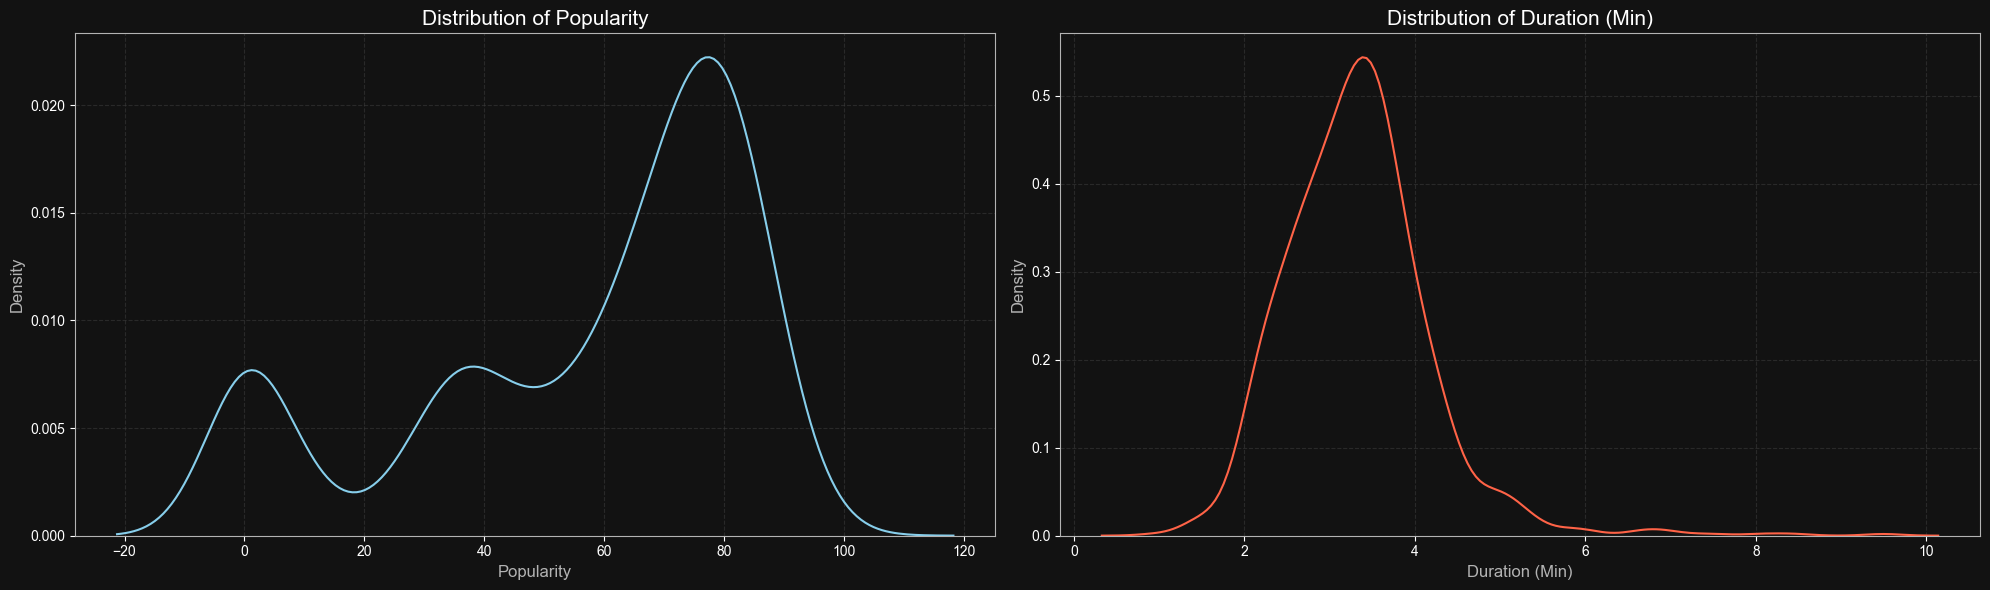

In [27]:
# --- Create Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6), facecolor=spotify_black)
for ax in axes:
    ax.set_facecolor(spotify_black)

# --- Plot 1: Popularity Distribution ---
sns.kdeplot(df['popularity'], color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Popularity', fontsize=15, color=spotify_white)
axes[0].set_xlabel('Popularity', fontsize=12, color=spotify_light_grey)
axes[0].set_ylabel('Density', fontsize=12, color=spotify_light_grey)
axes[0].tick_params(colors=spotify_white)
axes[0].grid(True, linestyle='--', color='#404040', alpha=0.5)

# --- Plot 2: Duration Distribution ---
sns.kdeplot(df['duration_min'], color='tomato', ax=axes[1])
axes[1].set_title('Distribution of Duration (Min)', fontsize=15, color=spotify_white)
axes[1].set_xlabel('Duration (Min)', fontsize=12, color=spotify_light_grey)
axes[1].set_ylabel('Density', fontsize=12, color=spotify_light_grey)
axes[1].tick_params(colors=spotify_white)
axes[1].grid(True, linestyle='--', color='#404040', alpha=0.5)

# --- Style tweaks ---
for ax in axes:
    for spine in ax.spines.values():
        spine.set_color(spotify_light_grey)

# --- Final Layout ---
plt.tight_layout()
plt.show()
plt.close(fig)